In [1]:
import os
import glob
import json
import pprint
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset

from pyperf.utils.patch_parser import SimplePatchParser
from pyperf.harness.utils import natural_sort_key
from pyperf.constants import SUBMISSIONS_DIR

pd.set_option("future.no_silent_downcasting", True)
# plt.rcParams.update({"font.size": 14})
pp = pprint.PrettyPrinter(indent=2)

In [2]:
def get_traces(pattern: str):
    traces = list(SUBMISSIONS_DIR.glob(pattern))
    if traces == []:
        print(f"Could not find any traces matching pattern: {pattern}")
    traces = sorted([str(t) for t in traces], key=natural_sort_key)
    return [Path(t) for t in traces]


def load_json(fname):
    with open(fname, "r") as f:
        return json.load(f)

In [3]:
HOME_DIR = Path(os.path.expanduser("~"))
EVAL_REPORTS_DIR = HOME_DIR / "pyperf/reports"


def get_model_config(model_alias: str):
    """
    Return the model configuration based on the model alias.

    Args:
        model_alias (str): The alias of the model, e.g. "claude" or "o3-mini".

    Returns:
        tuple: (model, beat_k, run_id_range)
    """
    if model_alias == "claude":
        model = "claude-3-5-sonnet-v2-20241022"
        beat_k = 15
    elif model_alias == "o3-mini":
        model = "o3-mini"
        beat_k = 10
    elif model_alias == "o4-mini":
        model = "o4-mini"
        beat_k = 10
    elif model_alias == "gpt-4o":
        model = "gpt-4o"
        beat_k = 15
    else:
        raise ValueError(f"Unknown model alias: {model_alias}")

    run_id_range = [0, beat_k]
    return model, beat_k, run_id_range


def load_evaluation_data(model_alias: str, beat_k: int, model: str):
    eval_report = (
        EVAL_REPORTS_DIR
        / "beat_k_reports"
        / f"{model_alias}.beat@{beat_k}.scale.report.json"
    )
    report = load_json(eval_report)
    traces = get_traces(
        f"manishs__pyperf-test/CodeActAgent/scale/{model}_maxiter_100_N_v0.35.0-no-hint-run_*/output.jsonl"
    )
    submissions = get_traces(
        f"manishs__pyperf-test/CodeActAgent/scale/{model}_maxiter_100_N_v0.35.0-no-hint-run_*/output.pyperf.jsonl"
    )
    return report, traces, submissions

#### Collect Dataset

In [4]:
dataset = load_dataset("manishs/pyperf-extended", split="test")

ignore_ids = ids = [
    "tornadoweb__tornado-0a39ba8",
    "numpy__numpy-8535df6",
    "tornadoweb__tornado-715ef05",
    "pandas-dev__pandas-00d88e9",
    "pandas-dev__pandas-1e03419",
    "pandas-dev__pandas-4583a04",
    "microsoft__onnxruntime-df28c7d",
    "numpy__numpy-4aca866",
    "python-pillow__Pillow-99760f4",
]
dataset = [i for i in dataset if i["instance_id"] not in ignore_ids]
print(f"Filtered dataset size: {len(dataset)}")

Filtered dataset size: 110


#### Collect Submissions

In [5]:
def load_traces_to_df(trace_files, run_id_range):
    traces_data = []

    for trace_file in tqdm(trace_files, desc="Loading trace files"):
        run_id = trace_file.parent.name  # Extract run ID from path

        run_id_num = int(run_id.split("_")[-1])
        if run_id_num < run_id_range[0] or run_id_num > run_id_range[1]:
            continue

        with open(trace_file, "r") as f:
            for line in f:
                try:
                    trace = json.loads(line)
                    if "instance_id" in trace:
                        trace["run_id"] = run_id
                        traces_data.append(trace)
                except json.JSONDecodeError:
                    continue

    traces_df = pd.DataFrame(traces_data)

    # Print info about the dataframe
    print(f"Loaded {len(traces_df)} trace entries")
    print(f"Unique instance IDs: {traces_df['instance_id'].nunique()}")
    print(f"Unique run IDs: {traces_df['run_id'].nunique()}")

    return traces_df

#### Collect Evaluations

In [6]:
def load_opt_stats_data(report, run_id_range):
    opt_stats = report["opt_stats"]
    opt_stats_data = []

    for instance_id, stats in opt_stats.items():
        run_id = stats["report_file"].split("/")[-1].rstrip("scale.report.json")
        run_id_num = int(run_id.split("_")[-1])
        if run_id_num < run_id_range[0] or run_id_num > run_id_range[1]:
            continue

        possible_reports = list(EVAL_REPORTS_DIR.glob(f"*{run_id}.scale.report.json"))
        if not possible_reports:
            continue

        report_path = possible_reports[0]
        with open(report_path, "r") as report_file:
            report_data = json.load(report_file)

        beat_commit = instance_id in report_data.get("instance_sets", {}).get(
            "beat_commit_ids", []
        )
        stats_dict = {
            "instance_id": instance_id,
            "run_id": run_id,
            "beat_commit": beat_commit,
            **stats,
        }
        opt_stats_data.append(stats_dict)

    # Convert to DataFrame
    opt_stats_df = pd.DataFrame(opt_stats_data)
    print(f"Loaded {len(opt_stats_df)} entries from opt_stats")

    return opt_stats_df

#### Merge

In [7]:
def merge_dataframes(traces_df, opt_stats_df, dataset):
    # Sort the traces dataframe
    traces_df = traces_df.sort_values(["instance_id", "run_id"])
    dataset_df = pd.DataFrame(dataset)

    # drop rows with instance_id not in dataset_df
    traces_df = traces_df[traces_df["instance_id"].isin(dataset_df["instance_id"])]
    opt_stats_df = opt_stats_df[
        opt_stats_df["instance_id"].isin(dataset_df["instance_id"])
    ]

    merged_df = pd.merge(
        traces_df,
        opt_stats_df,
        on=["instance_id", "run_id"],
        how="outer",
        suffixes=("_trace", "_stats"),
    )
    merged_df = pd.merge(
        merged_df,
        dataset_df,
        on="instance_id",
        how="outer",
        suffixes=("_merged", "_dataset"),
    )

    merged_df.fillna({"beat_commit": False}, inplace=True)

    print(f"Merged dataframe has {len(merged_df)} rows")
    print(f"Merged dataframe has {len(merged_df.columns)} columns")
    print(
        f"Instances with both trace and stats: {merged_df.dropna(subset=['instance_id', 'run_id']).shape[0]}"
    )

    return merged_df

#### Data Helpers

In [8]:
def get_diff_stats(patch, prefix=""):
    parser = SimplePatchParser()
    diff = parser.parse_patch(patch, old_commit_hash="")
    stats = {
        f"{prefix}num_files": diff.num_non_test_files,
        f"{prefix}num_hunks": diff.num_hunks,  # note: includes test files?
        f"{prefix}num_edited_lines": diff.num_non_test_edited_lines,
        f"{prefix}files_changed": [
            file_diff.path
            for file_diff in diff.file_diffs
            if file_diff.is_test_file is False
        ],
    }

    # remove any files starting with .venv or .git
    stats[f"{prefix}files_changed"] = [
        file
        for file in stats[f"{prefix}files_changed"]
        if not file.startswith((".venv", ".git"))
    ]

    stats[f"{prefix}extensions"] = extensions_from_filenames(
        stats[f"{prefix}files_changed"]
    )

    # update files_changed to only include good extensions
    stats[f"{prefix}files_changed"] = [
        file
        for file in stats[f"{prefix}files_changed"]
        if file.split(".")[-1] in stats[f"{prefix}extensions"]
    ]
    stats[f"{prefix}num_files"] = len(stats[f"{prefix}files_changed"])

    return stats


def extensions_from_filenames(files):
    ignore_list = {
        "rst",
        "txt",
        "json",
        "md",
        "csv",
        "pkl",
        "yaml",
        "yml",
        "mdx",
        "tif",
        "tiff",
        "png",
        "jpg",
        "jpeg",
        "gif",
        "webp",
        "bmp",
        "ico",
        "svg",
        "pdf",
        "gitignore",
        "lock",
        "zip",
        "tar",
        "gz",
        "bz2",
        "xz",
        "toml",
        "npy",
        "tmpl",
        "html",
        "build",
        "venv/lib64",
        "cfg",
        "patch",
    }
    extensions = {file.split(".")[-1] for file in files}
    return extensions - ignore_list

In [9]:
def get_agent_messages(history_list):
    if not history_list:
        return []

    return [
        {
            "id": item.get("id"),
            "message": item.get("message", ""),
            "timestamp": item.get("timestamp"),
        }
        for item in history_list
        if item.get("source") == "agent" and item.get("message")
    ]


def get_user_messages(history_list):
    if not history_list:
        return []

    return [
        {
            "id": item.get("id"),
            "message": item.get("message", ""),
            "timestamp": item.get("timestamp"),
        }
        for item in history_list
        if item.get("source") == "user" and item.get("message")
    ]


def get_tool_calls(history_list):
    if not history_list:
        return []

    tool_calls = []
    for item in history_list:
        if item.get("tool_call_metadata") and item.get("action"):
            try:
                metadata = item["tool_call_metadata"]
                function_name = metadata.get("function_name", "")
                tool_call_id = metadata.get("tool_call_id", "")
                step_id = item.get("id")

                # Extract command arguments if available
                arguments = None
                if (
                    metadata.get("model_response")
                    and metadata["model_response"].get("choices")
                    and metadata["model_response"]["choices"][0].get("message")
                    and metadata["model_response"]["choices"][0]["message"].get(
                        "tool_calls"
                    )
                ):

                    tool_call = metadata["model_response"]["choices"][0]["message"][
                        "tool_calls"
                    ][0]
                    if tool_call.get("function") and tool_call["function"].get(
                        "arguments"
                    ):
                        try:
                            arguments = json.loads(tool_call["function"]["arguments"])
                        except:
                            arguments = tool_call["function"]["arguments"]

                tool_calls.append(
                    {
                        "step_id": step_id,
                        "function_name": function_name,
                        "arguments": arguments,
                        "action": item.get("action"),
                    }
                )
            except Exception as e:
                # Skip tool calls that can't be parsed
                pass

    return tool_calls


def get_observations(history_list):
    if not history_list:
        return []

    observations = []
    for item in history_list:
        if not item.get("action") and item.get("cause"):
            observations.append(
                {
                    "id": item.get("id"),
                    "cause_id": item.get(
                        "cause"
                    ),  # Step ID that caused this observation
                    "message": item.get("message", ""),
                    "content": item.get("content", ""),
                    "error": item.get("error", ""),
                    "timestamp": item.get("timestamp"),
                    "success": item.get(
                        "success", True
                    ),  # Assume success unless explicitly marked as failed
                }
            )

    return observations


def get_action_sequence(history_list):
    if not history_list:
        return []

    return [
        {
            "step_id": item.get("id"),
            "action": item.get("action"),
            "timestamp": item.get("timestamp"),
            "source": item.get("source"),
        }
        for item in history_list
        if item.get("action")
    ]


def get_rebuilds(history_list):
    tool_calls = get_tool_calls(history_list)
    rebuilds = []
    for tool_call in tool_calls:
        if tool_call.get("arguments") and tool_call["arguments"].get("command"):
            command = tool_call["arguments"]["command"]
            if "pip install" in command:
                rebuilds.append(tool_call)
    return rebuilds


############# Counter functions #############
def get_step_counts(history_list):
    if not history_list:
        return 0

    return sum(1 for item in history_list if item.get("action"))


def get_action_counts(history_list):
    if not history_list:
        return {}

    action_counts = {}
    for item in history_list:
        action = item.get("action")
        if action:
            if action in action_counts:
                action_counts[action] += 1
            else:
                action_counts[action] = 1

    return action_counts


def get_conversation_summary(history):
    step_count = get_step_counts(history)
    action_counts = get_action_counts(history)
    rebuild_count = len(get_rebuilds(history))
    is_finished = action_counts.get("finish", 0) == 1

    return {
        "step_count": step_count,
        "action_counts": action_counts,
        "rebuild_count": rebuild_count,
        "is_finished": is_finished,
    }

In [10]:
def extract_per_test_times(per_test_means):
    if not per_test_means or (pd.isna(per_test_means)):
        return {
            "base_times": [],
            "patch_times": [],
            "commit_times": [],
            # "main_times": [],
        }
    return {
        f"{key}_times": value
        for key, value in per_test_means.items()
        if key in ["base", "patch", "commit"]
    }


def extract_per_test_speedups(per_test_means):
    if not per_test_means or pd.isna(per_test_means):
        return {
            f"{a}_{b}_speedups": []
            for a, b in [
                ("patch", "base"),
                ("commit", "base"),
                # ("main", "base"),
                ("patch", "commit"),
            ]
        }

    # Simple list comprehensions for each type of speedup
    result = {}

    # Calculate speedups with safe division
    result["patch_base_speedups"] = [
        b / p if p > 0 else float("inf")
        for b, p in zip(per_test_means["base"], per_test_means["patch"])
        if b > 0
    ]

    result["commit_base_speedups"] = [
        b / c if c > 0 else float("inf")
        for b, c in zip(per_test_means["base"], per_test_means["commit"])
        if b > 0
    ]

    # result["main_base_speedups"] = [
    #     b / m if m > 0 else float("inf")
    #     for b, m in zip(per_test_means["base"], per_test_means["main"])
    #     if b > 0
    # ]

    result["patch_commit_speedups"] = [
        c / p if p > 0 else float("inf")
        for c, p in zip(per_test_means["commit"], per_test_means["patch"])
        if c > 0
    ]

    return result

In [11]:
def prepare_analysis_row(df_row):
    # Extract relevant columns
    instance_id = df_row["instance_id"]
    run_id = df_row["run_id"]
    repo = df_row["repo"]
    api = df_row["api"]

    gt_commit = df_row["base_commit"].rstrip("^")
    gt_commit_link = f"https://github.com/{repo}/commit/{gt_commit}"
    gt_patch = df_row["gt_diff"]
    gt_files_changed = df_row["gt_files_changed"]
    gt_commit_stats = get_diff_stats(gt_patch, prefix="gt_")

    model_patch = df_row["test_result"].get("git_patch", "")
    model_patch_stats = get_diff_stats(model_patch, prefix="patch_")
    history = df_row["history"]

    # keep these optimization stats:
    stats_to_keep = [
        "opt_perc_patch_base",
        "opt_perc_patch_commit",
        # "opt_perc_patch_main",
        "speedup_patch_base",
        "speedup_patch_commit",
        # "speedup_patch_main",
        "gm_speedup_patch_base",
        "gm_speedup_patch_commit",
        # "gm_speedup_patch_main",
        "gsd_speedup_patch_base",
        "gsd_speedup_patch_commit",
        # "gsd_speedup_patch_main",
        "base_mean",
        "base_std",
        "patch_mean",
        "patch_std",
        "commit_mean",
        "commit_std",
        # "main_mean",
        # "main_std",
        "report_file",
    ]

    opt_stats = {k: df_row[k] for k in stats_to_keep if k in df_row}

    # Create a dictionary for the analysis row
    analysis_row = {
        "instance_id": instance_id,
        "run_id": run_id,
        "model_patch": model_patch,
        "gt_commit": gt_commit,
        "repo": repo,
        "repo_name": repo.split("/")[-1],
        "api": api,
        "gt_files_changed": gt_files_changed,
        "gt_patch": gt_patch,
        "gt_extensions": extensions_from_filenames(gt_files_changed),
        **gt_commit_stats,
        **model_patch_stats,
        **get_conversation_summary(history),
        **opt_stats,
        **extract_per_test_times(df_row["per_test_means"]),
        **extract_per_test_speedups(df_row["per_test_means"]),
    }

    # add the beat_commit renamed to beat
    analysis_row["beat"] = df_row["beat_commit"]

    return analysis_row


def make_analysis_df(merged_df):
    analysis_df = merged_df.apply(prepare_analysis_row, axis=1, result_type="expand")
    print(f"Analysis dataframe has {len(analysis_df)} rows")
    print(f"Analysis dataframe has {len(analysis_df.columns)} columns")
    return analysis_df

#### Plotting Helpers

In [12]:
def plot_beat_dist_by_column(analysis_df, column_name, figsize=(6, 3), rotation=30):
    grouped_df = (
        analysis_df.groupby(["instance_id", column_name])
        .agg({"beat": "max"})
        .reset_index()
    )
    success_rates = grouped_df.groupby(column_name)["beat"].mean() * 100
    plt.rcParams.update({"font.size": 11})
    plt.figure(figsize=figsize)
    ax = success_rates.plot(kind="bar", width=0.5, color="C0", edgecolor="black")

    # Add count labels above each bar
    # value_counts = grouped_df[column_name].value_counts()
    # for i, (_, rate) in enumerate(success_rates.items()):
    #     count = value_counts.get(success_rates.index[i], 0)
    #     ax.text(i, rate + 1, f"n={count}", ha="center", fontsize=8)

    # plt.title(f"% Problems beat by {column_name}")
    plt.ylabel("% Problems beat")
    plt.xticks(rotation=rotation, ha="center", fontsize=8)
    plt.grid(False)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

In [13]:
def plot_trajectory_vs_success(
    analysis_df, column_name, plot_type="boxplot", figsize=(6, 3)
):
    # Group by instance_id to determine success
    grouped_df = (
        analysis_df.groupby("instance_id")
        .agg({"beat": "max", column_name: "mean"})
        .reset_index()
    )

    # Create figure
    plt.rcParams.update({"font.size": 11})
    fig, ax = plt.subplots(figsize=figsize)
    y_label = None

    # Generate the appropriate plot type
    if plot_type == "boxplot":
        # Box plot
        sns.boxplot(
            x="beat",
            y=column_name,
            data=grouped_df,
            width=0.5,
            palette=["#D3D3D3", "C0"],
        )

        plt.xlabel("")
        ax.set_xticklabels(["Not Beaten", "Beaten"])
        plt.yscale("log")

    elif plot_type == "histogram":
        # Histogram overlaid
        bins = np.linspace(
            grouped_df[column_name].min(), grouped_df[column_name].max(), 20
        )

        for i, (name, group) in enumerate(grouped_df.groupby("beat")):
            label = "Beaten" if name else "Not Beaten"
            color = "C0" if name else "#D3D3D3"
            sns.histplot(
                group[column_name],
                bins=bins,
                alpha=0.6,
                label=label,
                color=color,
                # kde=True,
            )

        plt.legend()

    elif plot_type == "kde":
        # Kernel Density Estimation plot
        for i, (name, group) in enumerate(grouped_df.groupby("beat")):
            label = "Beaten" if name else "Not Beaten"
            color = "C0" if name else "#D3D3D3"
            sns.kdeplot(
                group[column_name],
                label=label,
                color=color,
                fill=True,
                alpha=0.4,
                clip=(0, None),
            )

        plt.xlim(left=0)
        plt.legend()
        y_label = "Probability Density"

    elif plot_type == "ecdf":
        # Empirical Cumulative Distribution Function
        for i, (name, group) in enumerate(grouped_df.groupby("beat")):
            label = "Beaten" if name else "Not Beaten"
            color = "C0" if name else "#D3D3D3"

            # Sort values and calculate ECDF
            x = np.sort(group[column_name])
            y = np.arange(1, len(x) + 1) / len(x)

            plt.plot(x, y, marker=".", linestyle="-", color=color, label=label)

        plt.legend()
        plt.grid(True, alpha=0.3)
        y_label = "Cumulative Probability"

    elif plot_type == "violin":
        # Violin plot with points
        sns.violinplot(
            x="beat",
            y=column_name,
            data=grouped_df,
            palette=["#D3D3D3", "C0"],
            inner="box",
        )

        # Add strip plot for individual points
        sns.stripplot(
            x="beat",
            y=column_name,
            data=grouped_df,
            size=3,
            color="black",
            alpha=0.3,
            jitter=True,
        )

        plt.xlabel("")
        ax.set_xticklabels(["Not Beaten", "Beaten"])

    # Common formatting
    plt.ylabel(y_label if y_label else column_name)
    plt.title(f"{column_name} vs. beat")
    plt.tight_layout()
    plt.show()

    # Print statistics
    # print(f"Statistics for {column_name} by beat status:")
    # print(grouped_df.groupby("beat")[column_name].describe())

In [14]:
def plot_ratio_distribution(analysis_df, colname, figsize=(6, 3)):
    # Create the full column names
    human_col = f"gt_{colname}"
    model_col = f"patch_{colname}"

    # Group by instance_id
    grouped_df = (
        analysis_df.groupby("instance_id")
        .agg({"beat": "max", human_col: "mean", model_col: "mean"})
        .reset_index()
    )

    # Calculate ratio (model / human)
    ratio_col = f"{colname}_ratio"
    grouped_df[ratio_col] = grouped_df[model_col] / grouped_df[human_col]
    plt.figure(figsize=figsize)

    # Plot histograms for beaten and not beaten
    for beat, group in grouped_df.groupby("beat"):
        label = "Beaten" if beat else "Not Beaten"
        plt.hist(
            group[ratio_col],
            bins=np.logspace(-2, np.log10(grouped_df[ratio_col].max()), 20),
            alpha=0.5,
            color="C0" if beat else "#D3D3D3",
            edgecolor="gray",
            linewidth=1,
            histtype="step",
            fill=True,
            label=label,
        )

    # Format plot
    plt.xscale("log")  # Log scale for better visualization of ratios
    plt.xlabel(f"Model/Human {colname}")
    plt.ylabel("Count")
    plt.title(f"Distribution of Model/Human {colname.replace('_', ' ').title()} Ratio")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Print stats
    total_count = len(grouped_df)
    beaten_count = grouped_df["beat"].sum()

    print(f"Model/Human {colname.replace('_', ' ').title()} Ratio Statistics:")
    print(f"Total instances: {total_count}")
    print(
        f"Model beats human in {beaten_count}/{total_count} cases ({beaten_count/total_count:.1%})"
    )

    for beat, group in grouped_df.groupby("beat"):
        status = "Beaten" if beat else "Not Beaten"
        print(f"\n{status} cases:")
        print(f"  Mean ratio: {group[ratio_col].mean():.4f}")
        print(f"  Median ratio: {group[ratio_col].median():.4f}")
        print(f"  Count: {len(group)}")

    # Check for invalid ratios (inf, NaN)
    invalid_ratios = grouped_df[~np.isfinite(grouped_df[ratio_col])]
    if len(invalid_ratios) > 0:
        print(
            f"\nWarning: {len(invalid_ratios)} instances have invalid ratios (division by zero or NaN)"
        )
        print("These may occur when human values are zero")

    # # warn about really low ratios with beat=True by showing the instance_id - model_col - human_col values
    # low_ratios = grouped_df.groupby("beat").get_group(True)[grouped_df[ratio_col] < 0.1]
    # if len(low_ratios) > 0:
    #     print(f"\nWarning: {len(low_ratios)} beaten instances have low ratios:")
    #     print(low_ratios[["instance_id", model_col, human_col]])

    plt.tight_layout()
    plt.show()

In [15]:
def plot_slowdown_histogram(per_test_speedups_df, col_name):
    # Create more detailed slowdown ranges with 0% as a separate category
    slowdown_ranges = [(0, 0), (0.1, 10), (10, 30), (30, 50), (50, 70), (70, 100)]
    counts = []

    for low, high in slowdown_ranges:
        if low == 0 and high == 0:
            # Count cases with exactly 0% slowdowns
            count = len(per_test_speedups_df[per_test_speedups_df[col_name] == 0])
        else:
            # Count cases in the range, making sure not to double-count 0%
            count = len(
                per_test_speedups_df[
                    (per_test_speedups_df[col_name] > low)
                    & (per_test_speedups_df[col_name] <= high)
                ]
            )
        counts.append(count)

    # Calculate percentage of perfect cases (0% slowdowns)
    perfect_pct = counts[0] / sum(counts) * 100

    header = " wrt ".join(
        col_name.replace("perc_", "").replace("_slowdowns", "").split("_")
    )

    # set small font size for the plot
    plt.rcParams.update({"font.size": 10})

    # Create the histogram
    labels = ["0%", "0.1-10%", "10-30%", "30-50%", "50-70%", "70-100%"]
    plt.figure(figsize=(4, 3))
    bars = plt.bar(labels, counts, width=0.4)
    plt.title(f"%Tests w/ slowdowns for {header}")
    plt.xlabel("%Tests with Slowdowns")
    plt.ylabel("Number of Instances")
    plt.ylim(0, max(counts) + 3)
    plt.xticks(rotation=45)

    # Add count labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.1,
            f"{height:.0f}",
            ha="center",
            va="bottom",
        )
    plt.tight_layout()
    plt.show()

    # Calculate and print additional statistics
    print(f"Number of patches with 0% slowdowns: {counts[0]} ({perfect_pct:.1f}%)")
    total = sum(counts)
    over_50 = sum(counts[4:6])
    over_30 = sum(counts[3:6])
    print(
        f"Number of patches with >30% slowdowns: {over_30} ({over_30/total*100:.1f}%)"
    )

#### Analysis

In [16]:
# model_alias = "o3-mini"
# model, beat_k, run_id_range = get_model_config(model_alias)
# report, traces, submissions = load_evaluation_data(model_alias, beat_k, model)
# traces_df = load_traces_to_df(traces, run_id_range)
# opt_stats_df = load_opt_stats_data(report, run_id_range)
# merged_df = merge_dataframes(traces_df, opt_stats_df, dataset)
# analysis_df = make_analysis_df(merged_df)


# model_alias = "claude"
# model, beat_k, run_id_range = get_model_config(model_alias)
# report, traces, submissions = load_evaluation_data(model_alias, beat_k, model)
# traces_df = load_traces_to_df(traces, run_id_range)
# opt_stats_df = load_opt_stats_data(report, run_id_range)
# merged_df = merge_dataframes(traces_df, opt_stats_df, dataset)
# analysis_df = make_analysis_df(merged_df)


# model_alias = "gpt-4o"
# model, beat_k, run_id_range = get_model_config(model_alias)
# report, traces, submissions = load_evaluation_data(model_alias, beat_k, model)
# traces_df = load_traces_to_df(traces, run_id_range)
# opt_stats_df = load_opt_stats_data(report, run_id_range)
# merged_df = merge_dataframes(traces_df, opt_stats_df, dataset)
# analysis_df = make_analysis_df(merged_df)


model_alias = "o4-mini"
model, beat_k, run_id_range = get_model_config(model_alias)
report, traces, submissions = load_evaluation_data(model_alias, beat_k, model)
traces_df = load_traces_to_df(traces, run_id_range)
opt_stats_df = load_opt_stats_data(report, run_id_range)
merged_df = merge_dataframes(traces_df, opt_stats_df, dataset)
analysis_df = make_analysis_df(merged_df)

Loading trace files: 100%|██████████| 10/10 [00:08<00:00,  1.24it/s]


Loaded 1190 trace entries
Unique instance IDs: 119
Unique run IDs: 10
Loaded 20 entries from opt_stats
Merged dataframe has 1100 rows
Merged dataframe has 47 columns
Instances with both trace and stats: 1100
Analysis dataframe has 1100 rows
Analysis dataframe has 44 columns


##### Dist of beat wrt X

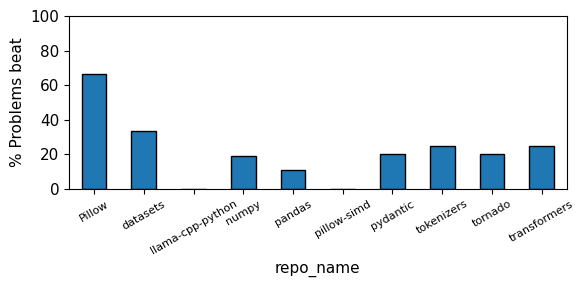

In [17]:
plot_beat_dist_by_column(analysis_df, "repo_name")

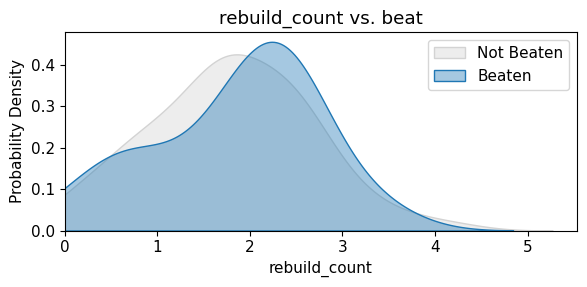

In [18]:
plot_trajectory_vs_success(analysis_df, "rebuild_count", plot_type="kde")

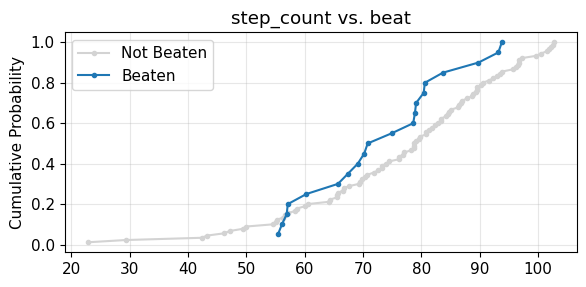

In [19]:
plot_trajectory_vs_success(analysis_df, "step_count", plot_type="ecdf")

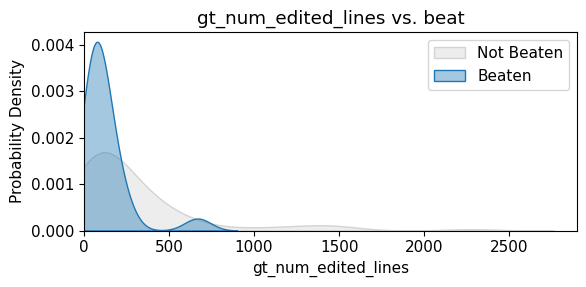

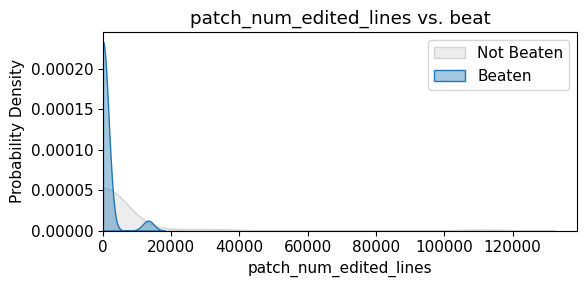

In [20]:
plot_trajectory_vs_success(analysis_df, "gt_num_edited_lines", plot_type="kde")
plot_trajectory_vs_success(analysis_df, "patch_num_edited_lines", plot_type="kde")

Model/Human Num Edited Lines Ratio Statistics:
Total instances: 110
Model beats human in 20/110 cases (18.2%)

Not Beaten cases:
  Mean ratio: 21.2269
  Median ratio: 0.1564
  Count: 90

Beaten cases:
  Mean ratio: 6.6897
  Median ratio: 0.2819
  Count: 20


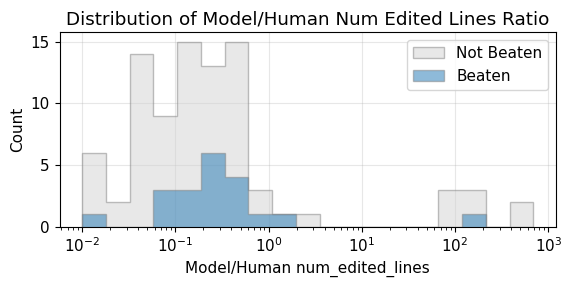

In [21]:
plot_ratio_distribution(analysis_df, "num_edited_lines")

##### Model-Human Agreement

In [22]:
def analyze_patch_vs_gt(analysis_df, feature_name="extensions", figsize=(6, 3)):
    import matplotlib.pyplot as plt
    from collections import Counter
    import pandas as pd

    # Ensure the feature exists in the dataset
    gt_col = f"gt_{feature_name}"
    patch_col = f"patch_{feature_name}"

    # Use raw dataframe
    grouped_df = (
        analysis_df.groupby("instance_id")
        .agg({"beat": "max", gt_col: "first", patch_col: "first"})
        .reset_index()
    )

    # Convert lists to sets for easier comparison
    grouped_df[gt_col] = grouped_df[gt_col].apply(
        lambda x: set(x) if isinstance(x, list) else x
    )
    grouped_df[patch_col] = grouped_df[patch_col].apply(
        lambda x: set(x) if isinstance(x, list) else x
    )

    # Filter out rows where either gt or patch data is empty
    grouped_df = grouped_df[grouped_df[gt_col].apply(lambda x: len(x) > 0)]
    grouped_df = grouped_df[grouped_df[patch_col].apply(lambda x: len(x) > 0)]

    # Calculate match metrics
    grouped_df["exact_match"] = grouped_df.apply(
        lambda row: row[gt_col] == row[patch_col], axis=1
    )
    grouped_df["partial_match"] = grouped_df.apply(
        lambda row: (
            len(row[gt_col] & row[patch_col]) > 0 if len(row[gt_col]) > 0 else False
        ),
        axis=1,
    )
    grouped_df["no_match"] = ~grouped_df["partial_match"]

    # Calculate agreement categories for analysis
    grouped_df["agreement_type"] = "Disagree"
    grouped_df.loc[
        grouped_df["partial_match"] & ~grouped_df["exact_match"], "agreement_type"
    ] = "Partial"
    grouped_df.loc[grouped_df["exact_match"], "agreement_type"] = "Agree"

    # Calculate missing and extra elements
    grouped_df["missing_elements"] = grouped_df.apply(
        lambda row: row[gt_col] - row[patch_col], axis=1
    )
    grouped_df["extra_elements"] = grouped_df.apply(
        lambda row: row[patch_col] - row[gt_col], axis=1
    )

    # =====================================================
    # Plot 1: SIMPLIFIED - Agreement vs Beat Rate
    # =====================================================
    plt.figure(figsize=figsize)

    # Create match categories
    grouped_df["match_category"] = "Disagree"
    grouped_df.loc[
        grouped_df["partial_match"] & ~grouped_df["exact_match"], "match_category"
    ] = "Partial"
    grouped_df.loc[grouped_df["exact_match"], "match_category"] = "Agree"

    # Calculate percentage of instances in each category
    total_instances = len(grouped_df)
    category_counts = grouped_df["match_category"].value_counts()
    category_percentages = (category_counts / total_instances) * 100

    # Calculate beat counts and rates for each category
    beat_counts = grouped_df[grouped_df["beat"]].groupby("match_category").size()
    beat_percentages_within_category = (beat_counts / category_counts) * 100

    # Calculate percentage of total instances that are beaten in each category
    beat_percentages_of_total = (beat_counts / total_instances) * 100

    # Combine data for plotting
    categories = ["Agree", "Partial", "Disagree"]
    cat_percentages = [category_percentages.get(cat, 0) for cat in categories]
    beat_within_cat = [
        beat_percentages_within_category.get(cat, 0) for cat in categories
    ]
    beat_of_total = [beat_percentages_of_total.get(cat, 0) for cat in categories]

    # Create the stacked bar plot
    fig, ax = plt.subplots(figsize=figsize)

    # Create stacked bars
    bottom_vals = [0, 0, 0]

    # Non-beaten instances
    non_beat_vals = [
        cat_percentages[i] - beat_of_total[i] for i in range(len(categories))
    ]
    bars1 = ax.bar(
        categories,
        non_beat_vals,
        bottom=bottom_vals,
        color="#D3D3D3",
        label="Not Beaten",
    )

    # Update bottom values
    bottom_vals = non_beat_vals

    # Beaten instances
    bars2 = ax.bar(
        categories, beat_of_total, bottom=bottom_vals, color="C0", label="Beaten"
    )

    # Add data labels on bars
    for i, (cat, nb_val, b_val) in enumerate(
        zip(categories, non_beat_vals, beat_of_total)
    ):
        # Category percentage
        cat_pct = cat_percentages[i]
        ax.text(
            i,
            cat_pct + 1,
            f"{cat_pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
        )

        # Beat percentage within category (if significant)
        if b_val > 0.5:
            ax.text(
                i,
                nb_val + b_val / 2,
                f"{beat_within_cat[i]:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold",
            )

    ax.set_ylabel("% of All Instances")
    ax.set_ylim(0, max(cat_percentages) * 1.2)
    plt.title(f"Model-Human Agreement on {feature_name.capitalize()}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 2: Extra and Missing Elements in a Single Plot
    # =====================================================
    plt.figure(figsize=figsize)

    # Get common elements for both lists
    all_missing = [
        item for sublist in grouped_df["missing_elements"] for item in sublist if item
    ]
    missing_counter = Counter(all_missing)

    all_extra = [
        item for sublist in grouped_df["extra_elements"] for item in sublist if item
    ]
    extra_counter = Counter(all_extra)

    # Combine top elements from both sides to create a unified list
    missing_top = [item for item, _ in missing_counter.most_common(5)]
    extra_top = [item for item, _ in extra_counter.most_common(5)]

    # Find common elements in both sets to keep on the same row
    common_elements = set(missing_top) & set(extra_top)
    all_elements = (
        list(common_elements)
        + [x for x in missing_top if x not in common_elements]
        + [x for x in extra_top if x not in common_elements]
    )
    all_elements = all_elements[:10]  # Limit to max 10 elements

    # Create a mapping of percentages
    missing_pct = {
        item: count / len(grouped_df) * 100 for item, count in missing_counter.items()
    }
    extra_pct = {
        item: count / len(grouped_df) * 100 for item, count in extra_counter.items()
    }

    # Create a stacked/diverging horizontal bar chart
    fig, ax = plt.subplots(figsize=(figsize[0], figsize[1]))

    # Generate y positions
    y_pos = range(len(all_elements))

    # Create bars for missing elements (left side, negative values)
    missing_vals = [-missing_pct.get(elem, 0) for elem in all_elements]
    missing_bars = ax.barh(
        y_pos,
        missing_vals,
        align="center",
        color="C3",
        alpha=0.7,
        label="Missing Elements",
    )

    # Create bars for extra elements (right side, positive values)
    extra_vals = [extra_pct.get(elem, 0) for elem in all_elements]
    extra_bars = ax.barh(
        y_pos, extra_vals, align="center", color="C2", alpha=0.7, label="Extra Elements"
    )

    # Add value labels inside the bars
    for i, bar in enumerate(missing_bars):
        width = bar.get_width()
        if width < -1:  # Only add text if the bar is wide enough
            ax.text(
                width / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{abs(width):.1f}%",
                ha="center",
                va="center",
                color="white",
                fontweight="bold",
                fontsize=9,
            )

    for i, bar in enumerate(extra_bars):
        width = bar.get_width()
        if width > 1:  # Only add text if the bar is wide enough
            ax.text(
                width / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontweight="bold",
                fontsize=9,
            )

    # Set labels and ticks
    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_elements)
    ax.set_xlabel("% of All Cases")

    # Add a vertical line at x=0
    ax.axvline(x=0, color="k", linestyle="-", alpha=0.3)

    # Add explanatory labels above the chart
    ax.text(
        -max(abs(min(missing_vals)), max(extra_vals)) / 2,
        len(all_elements) + 0.3,
        "Missing in Model Patch",
        ha="center",
        fontsize=10,
        color="C3",
        fontweight="bold",
    )
    ax.text(
        max(abs(min(missing_vals)), max(extra_vals)) / 2,
        len(all_elements) + 0.3,
        "Extra in Model Patch",
        ha="center",
        fontsize=10,
        color="C2",
        fontweight="bold",
    )

    # Get current x-axis tick labels
    x_ticks = ax.get_xticks()
    # Replace negative values with positive ones
    ax.set_xticklabels([f"{abs(int(tick))}%" for tick in x_ticks])

    # Adjust x-axis limits to make the plot symmetrical
    x_max = max(abs(min(missing_vals)), max(extra_vals)) * 1.1
    ax.set_xlim(-x_max, x_max)
    ax.grid(True, axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

<Figure size 600x300 with 0 Axes>

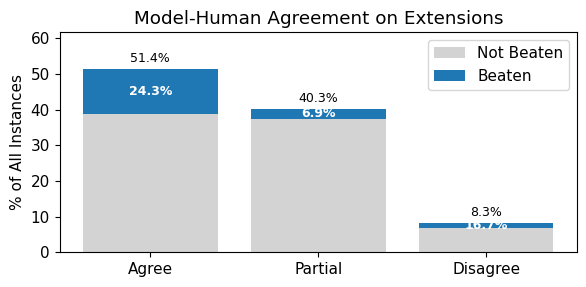

/tmp/ipykernel_582605/1422966650.py:270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(int(tick))}%" for tick in x_ticks])


<Figure size 600x300 with 0 Axes>

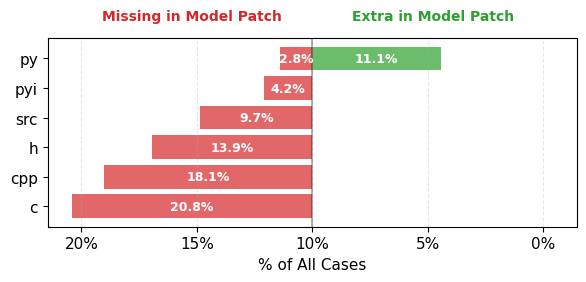

<Figure size 600x300 with 0 Axes>

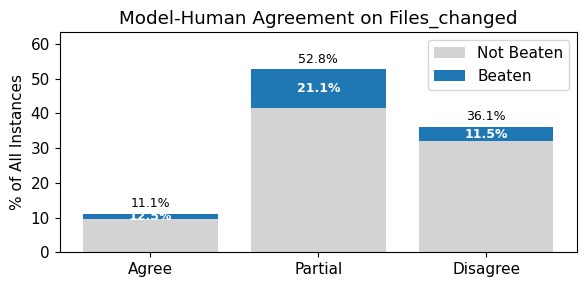

/tmp/ipykernel_582605/1422966650.py:270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(int(tick))}%" for tick in x_ticks])


<Figure size 600x300 with 0 Axes>

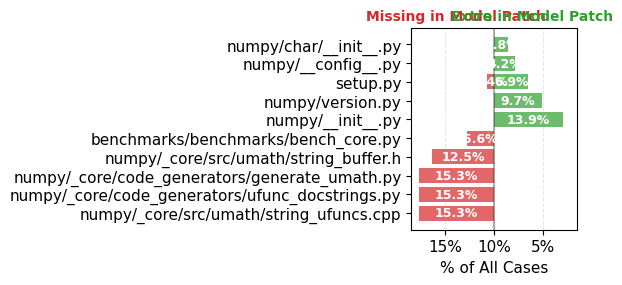

In [23]:
analyze_patch_vs_gt(analysis_df, "extensions")
analyze_patch_vs_gt(analysis_df, "files_changed")  # figsize=(10, 5))

##### Analysis of speedup variations across tests

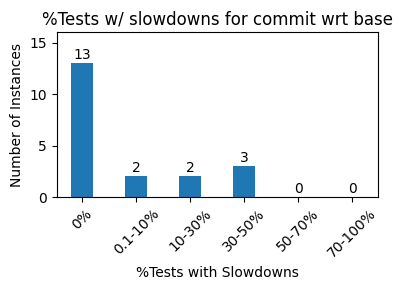

Number of patches with 0% slowdowns: 13 (65.0%)
Number of patches with >30% slowdowns: 3 (15.0%)


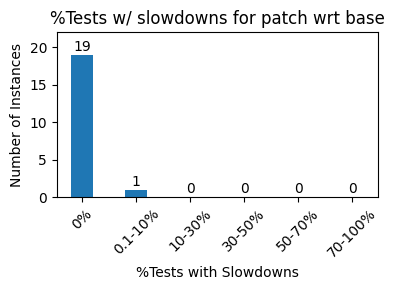

Number of patches with 0% slowdowns: 19 (95.0%)
Number of patches with >30% slowdowns: 0 (0.0%)


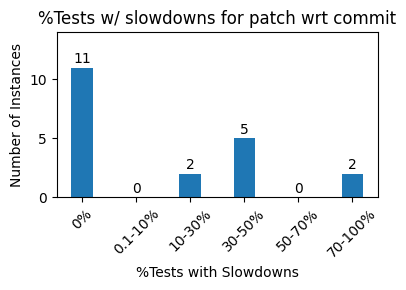

Number of patches with 0% slowdowns: 11 (55.0%)
Number of patches with >30% slowdowns: 7 (35.0%)


In [24]:
def calc_percent_slowdowns(speedups_list):
    slowdowns = [speed for speed in speedups_list if speed < 1.0]
    return len(slowdowns) / len(speedups_list) * 100 if len(speedups_list) > 0 else 0


per_test_speedups_df = analysis_df[analysis_df["beat"] == True]
per_test_speedups_df = per_test_speedups_df.assign(
    **{
        f"perc_{old.replace('_speedups','')}_slowdowns": per_test_speedups_df[
            old
        ].apply(calc_percent_slowdowns)
        for old in [
            "commit_base_speedups",
            "patch_base_speedups",
            "patch_commit_speedups",
        ]
    }
)

plot_slowdown_histogram(per_test_speedups_df, "perc_commit_base_slowdowns")
plot_slowdown_histogram(per_test_speedups_df, "perc_patch_base_slowdowns")
plot_slowdown_histogram(per_test_speedups_df, "perc_patch_commit_slowdowns")